In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving roses.jpeg to roses (1).jpeg
Saving sunflowers.jpeg to sunflowers (1).jpeg


In [ ]:
img1 = cv2.imread("roses (1).jpeg", 0)
img2 = cv2.imread("sunflowers (1).jpeg", 0)


img1 = cv2.resize(img1, (256, 256))
img2 = cv2.resize(img2, (256, 256))

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

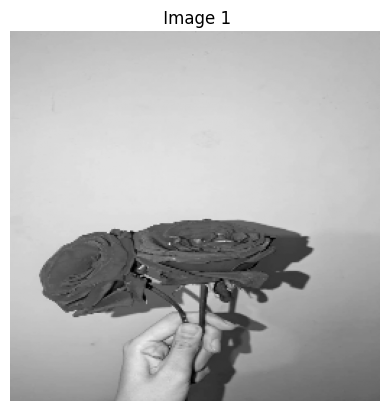

In [ ]:
plt.imshow(img1, cmap='gray')
plt.title(" Image 1")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

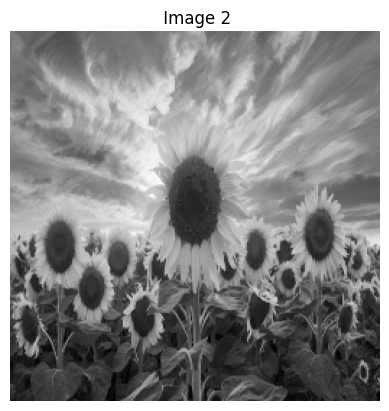

In [ ]:
plt.imshow(img2, cmap='gray')
plt.title(" Image 2")
plt.axis("off")

In [ ]:

img1_shift = np.right_shift(img1, 2)

img1_shift = np.left_shift(img1_shift, 2)

img2_shift = np.right_shift(img2, 6)

stego = cv2.bitwise_or(img1_shift, img2_shift)


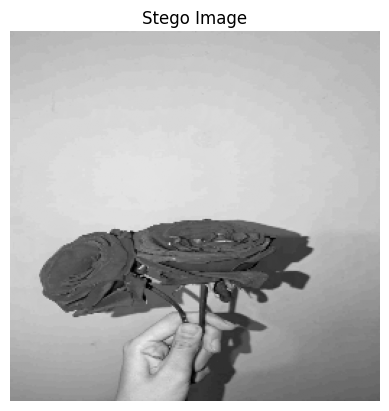

In [ ]:
plt.imshow(stego, cmap='gray')

plt.title("Stego Image")
plt.axis("off")
plt.show()

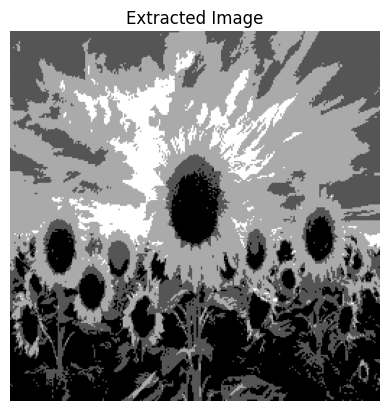

In [ ]:
extracted = np.left_shift(stego, 6)

plt.imshow(extracted, cmap='gray')
plt.title("Extracted Image")
plt.axis("off")
plt.show()

In [ ]:

def get_neighbors(x, y, image):
    rows, cols = image.shape
    neighbors_4 = []
    neighbors_8 = []

    # 4-neighbors
    if x > 0: neighbors_4.append((x-1, y))
    if x < rows-1: neighbors_4.append((x+1, y))
    if y > 0: neighbors_4.append((x, y-1))
    if y < cols-1: neighbors_4.append((x, y+1))

    # 8-neighbors (include diagonals)
    for i in range(x-1, x+2):
        for j in range(y-1, y+2):
            if (i,j) != (x,y) and 0 <= i < rows and 0 <= j < cols:
                neighbors_8.append((i,j))

    return neighbors_4, neighbors_8

# Example: neighbors of pixel (100,100)
n4, n8 = get_neighbors(100,100,img1)
print("4-neighbors of (100,100):", n4)
print("8-neighbors of (100,100):", n8)


4-neighbors of (100,100): [(99, 100), (101, 100), (100, 99), (100, 101)]
8-neighbors of (100,100): [(99, 99), (99, 100), (99, 101), (100, 99), (100, 101), (101, 99), (101, 100), (101, 101)]


In [ ]:
def is_connected(p1, p2, image):
# Check if two pixels have similar intensity
  if abs(int(image[p1]) - int(image[p2])) < 10:
    return True   # Connected
  else:
    return False  # Not connected

In [ ]:
# Example path between two points
path = [(0,0), (0,1), (1,1), (2,1)]
# Sequence of connected pixels
print("Path:", path)

Path: [(0, 0), (0, 1), (1, 1), (2, 1)]
